1. IMPORT LIBRARIES

In [30]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

2. LOAD DATASET

In [31]:
df = pd.read_csv("train.csv", encoding="latin1")

In [32]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [34]:
df.describe()

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


In [35]:
print("Dataset Shape:", df.shape)

print("\nColumns:")

print(df.columns)

Dataset Shape: (9800, 18)

Columns:
Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='object')


3. DATA CLEANING

In [36]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [37]:
df.drop(columns=["Postal Code"], inplace=True)

In [38]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [39]:
df.duplicated().sum()

df.drop_duplicates(inplace=True)

In [40]:
# CREATE TIME COLUMNS AND CONVERT THEM TO PROPER FORMAT

df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)

df["Year"] = df["Order Date"].dt.year

df["Month"] = df["Order Date"].dt.month_name()

df["Month Number"] = df["Order Date"].dt.month

df["Quarter"] = df["Order Date"].dt.quarter

4. VISUALIZATIONS

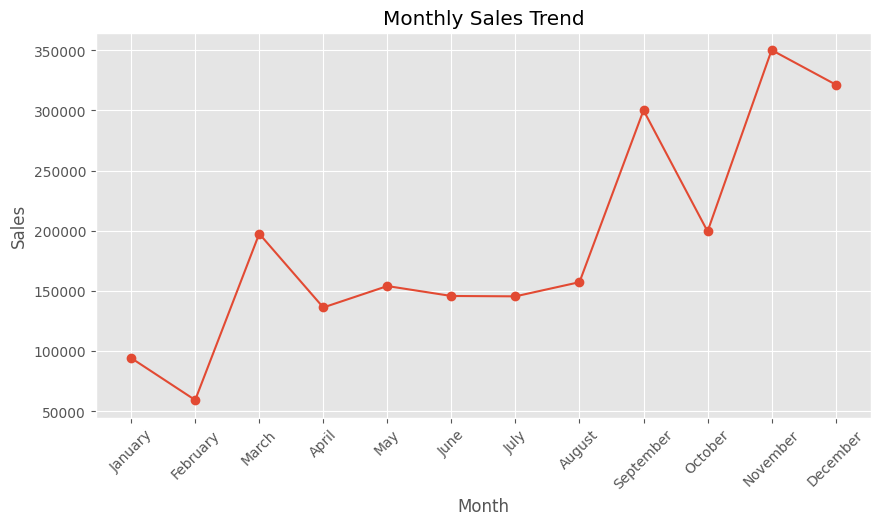

In [41]:
# Monthly Sales

monthly_sales = df.groupby(["Month Number", "Month"])["Sales"].sum().reset_index()

plt.figure(figsize=(10,5))
plt.plot(monthly_sales["Month"], monthly_sales["Sales"], marker='o')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()

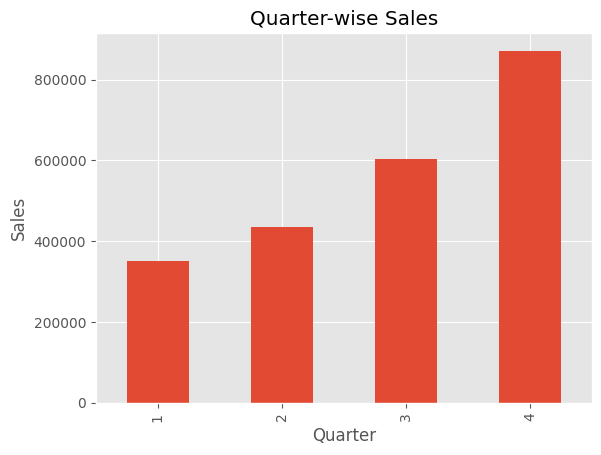

In [42]:
# Seasonal Analysis

quarter_sales = df.groupby("Quarter")["Sales"].sum()

quarter_sales.plot(kind="bar")

plt.title("Quarter-wise Sales")

plt.xlabel("Quarter")

plt.ylabel("Sales")

plt.show()

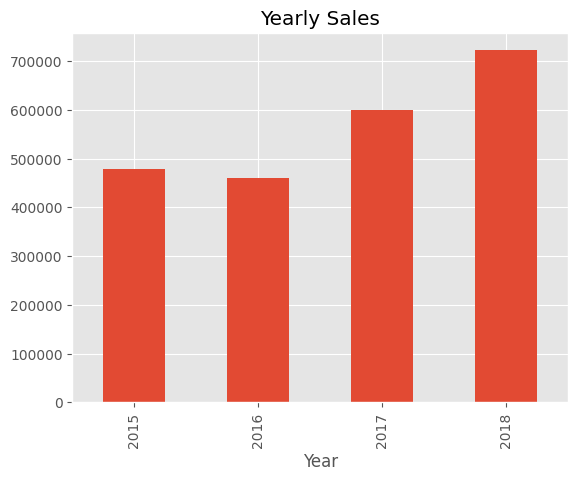

In [43]:
# Yearly Sales

yearly_sales = df.groupby("Year")["Sales"].sum()

yearly_sales.plot(kind="bar")

plt.title("Yearly Sales")

plt.show()

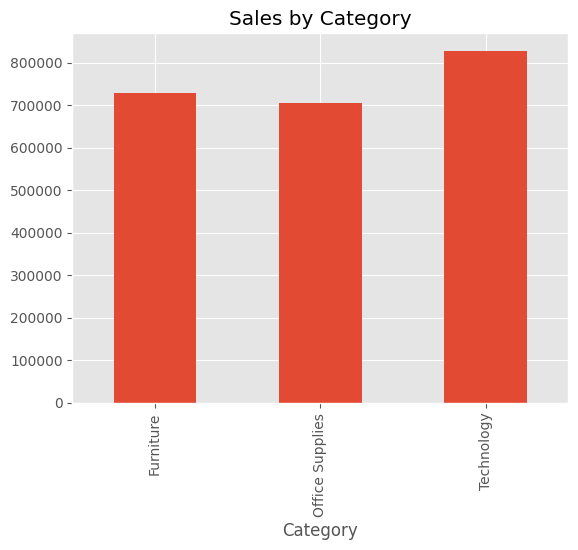

In [44]:
# Category wise Sales

category = df.groupby("Category")["Sales"].sum()

category.plot(kind="bar")

plt.title("Sales by Category")

plt.show()

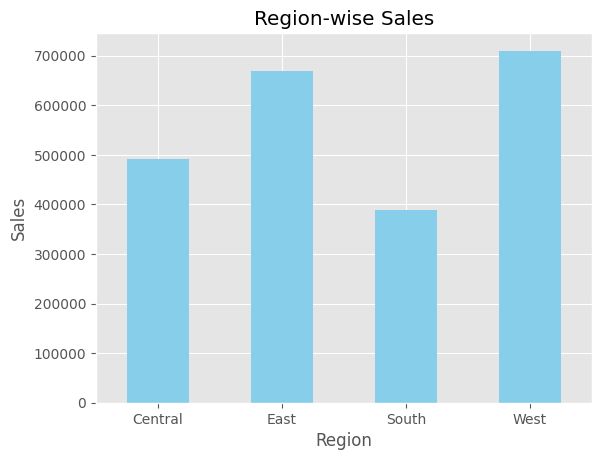

In [45]:
# Region wise Sales

region = df.groupby("Region")["Sales"].sum()

region.plot(kind="bar", color="skyblue")

plt.xlabel("Region")
plt.ylabel("Sales")
plt.title("Region-wise Sales")
plt.xticks(rotation=0)

plt.show()

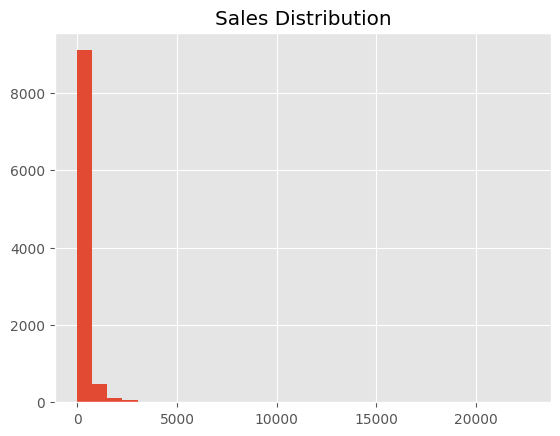

In [46]:
 # Sales Distribution

plt.hist(df["Sales"], bins=30)

plt.title("Sales Distribution")

plt.show()

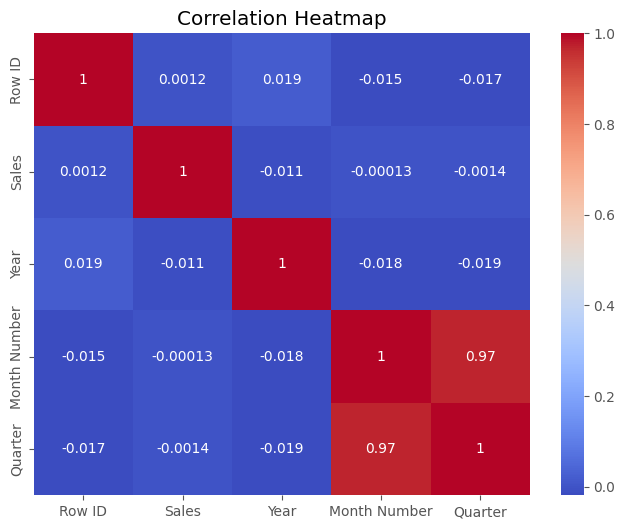

In [47]:
# Correlation map

plt.figure(figsize=(8,6))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

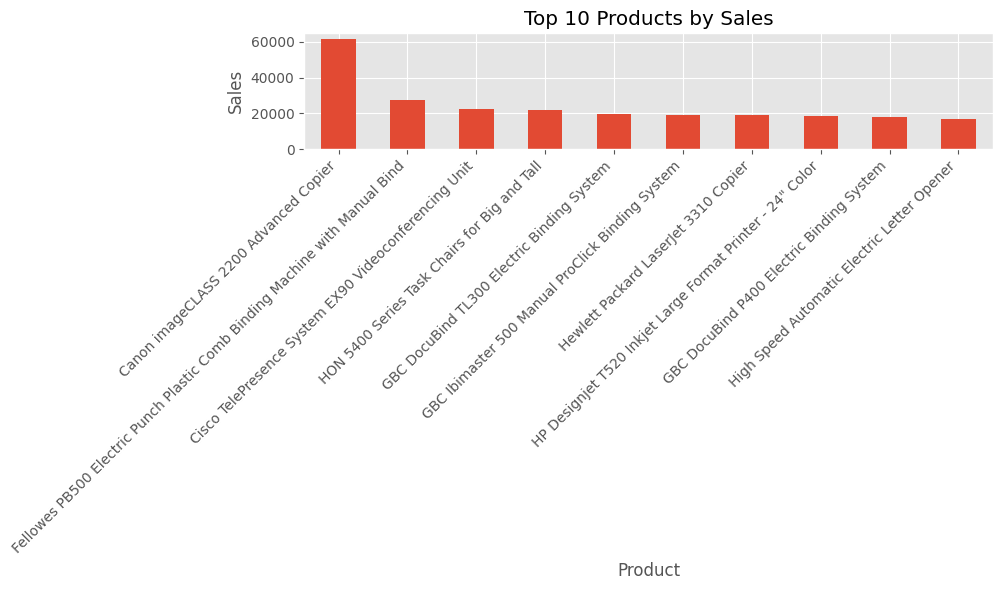

In [48]:
top_products = (
    df.groupby("Product Name")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,6))
top_products.plot(kind="bar")
plt.title("Top 10 Products by Sales")
plt.xlabel("Product")
plt.ylabel("Sales")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [51]:
from google.colab import files

df.to_csv("cleaned_sales.csv", index=False)
files.download("cleaned_sales.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

5. INSIGHTS

**1. Monthly Sales Trend**

Sales fluctuate throughout the year, indicating seasonal demand. Certain months generate significantly higher sales than others, which may be influenced by holidays, promotions, or customer buying behavior.

-------------------------------------------------------------------------------


**2. Quarter-wise Sales**

Quarterly analysis shows variations in sales performance, highlighting seasonal patterns. Businesses can use this information to plan inventory and marketing strategies during high-demand quarters.

-------------------------------------------------------------------------------

**3. Yearly Sales Trend**

Yearly sales indicate the overall business performance over time. An increasing trend suggests business growth, while fluctuations may reflect changing market conditions.

-------------------------------------------------------------------------------

**4. Category-wise Sales**

Product categories contribute differently to total sales. The category with the highest sales represents the primary revenue source, while lower-performing categories may require promotional efforts or strategic improvements.

-------------------------------------------------------------------------------

**5. Region-wise Sales**

Sales performance varies across different regions. High-performing regions contribute significantly to overall revenue, whereas lower-performing regions may present opportunities for targeted marketing and business expansion.

-------------------------------------------------------------------------------

**6. Sales Distribution**

The sales distribution indicates that most transactions fall within a lower sales range, while a smaller number of transactions contribute exceptionally high sales values. This suggests the presence of a few high-value orders.

-------------------------------------------------------------------------------

**7. Correlation Heatmap**

The correlation analysis illustrates the relationships between numerical variables. Variables with strong positive correlations may have a significant influence on each other and can be valuable for future predictive modeling.

-------------------------------------------------------------------------------

**8. Top 10 Products**

The Top 10 Products analysis identifies the highest revenue-generating products. These products play a crucial role in overall business performance and should be prioritized for inventory management and marketing campaigns.

6. CONCLUSION

The sales dataset was successfully cleaned and analyzed using Python. Exploratory Data Analysis revealed important trends, seasonal patterns, regional performance, and top-performing product categories. These insights provide valuable information for business decision-making and establish a reliable foundation for the forecasting model and interactive dashboard to be developed in the next phase of the project.